<a href="https://colab.research.google.com/github/joshua2705/Loan-Risk-Model-Outcome-Comparison/blob/Decision-Tree/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Environment setup

In [1]:
! pip install kaggle
! pip install kagglehub
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

#! kaggle datasets download -d averkiyoliabev/home-equity-line-of-creditheloc

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("averkiyoliabev/home-equity-line-of-creditheloc")

print("Path to dataset files:", path)

100%|██████████| 204k/204k [00:00<00:00, 27.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/averkiyoliabev/home-equity-line-of-creditheloc/versions/1


In [3]:
! ls  /root/.cache/kagglehub/datasets/averkiyoliabev/home-equity-line-of-creditheloc/versions/1


'heloc_dataset_v1 (1).csv'


In [4]:
! pip install optbinning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 15.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatible.


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [7]:


from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

#Preprocessing

In [8]:
df = pd.read_csv("/root/.cache/kagglehub/datasets/averkiyoliabev/home-equity-line-of-creditheloc/versions/1/heloc_dataset_v1 (1).csv", sep=",")

#/kaggle/input/home-equity-line-of-creditheloc/heloc_dataset_v1 (1).csv

In [9]:
variable_names = list(df.columns[1:])

In [10]:
X = df[variable_names].values

In [11]:
# Transform target variable into numerical.

y = df.RiskPerformance.values
mask = y == "Bad"
y[mask] = 1
y[~mask] = 0
y = y.astype(int)

# Hyperparameter Tuning

In [50]:
# Split dataset

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42)


In [51]:
#Hyperparameter Tuning with GridSearch



dt_params = {
    'max_depth': [5, 6, 7],
    'min_samples_leaf': [20, 40, 50],
    'criterion': ['gini', 'entropy'],
    'ccp_alpha': [0.0, 0.001, 0.0015],
}


grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train_dt, y_train_dt)



GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'ccp_alpha': [0.0, 0.001, 0.0015],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7],
                         'min_samples_leaf': [20, 40, 50]},
             scoring='accuracy')

In [52]:
#Model Performance

best_dt = grid_dt.best_estimator_
acc_dt = accuracy_score(y_test_dt, best_dt.predict(X_test_dt))

print(f" Decision Tree Accuracy: {acc_dt:.2%}")
print(f"   (Best Depth: {grid_dt.best_params_['max_depth']})")
print(f"   (Best min_samples_leaf: {grid_dt.best_params_['min_samples_leaf']})")
print(f"   (Best criterion: {grid_dt.best_params_['criterion']})")
print(f"   (Best ccp_alpha: {grid_dt.best_params_['ccp_alpha']})")

 Decision Tree Accuracy: 70.03%
   (Best Depth: 5)
   (Best min_samples_leaf: 20)
   (Best criterion: gini)
   (Best ccp_alpha: 0.0)


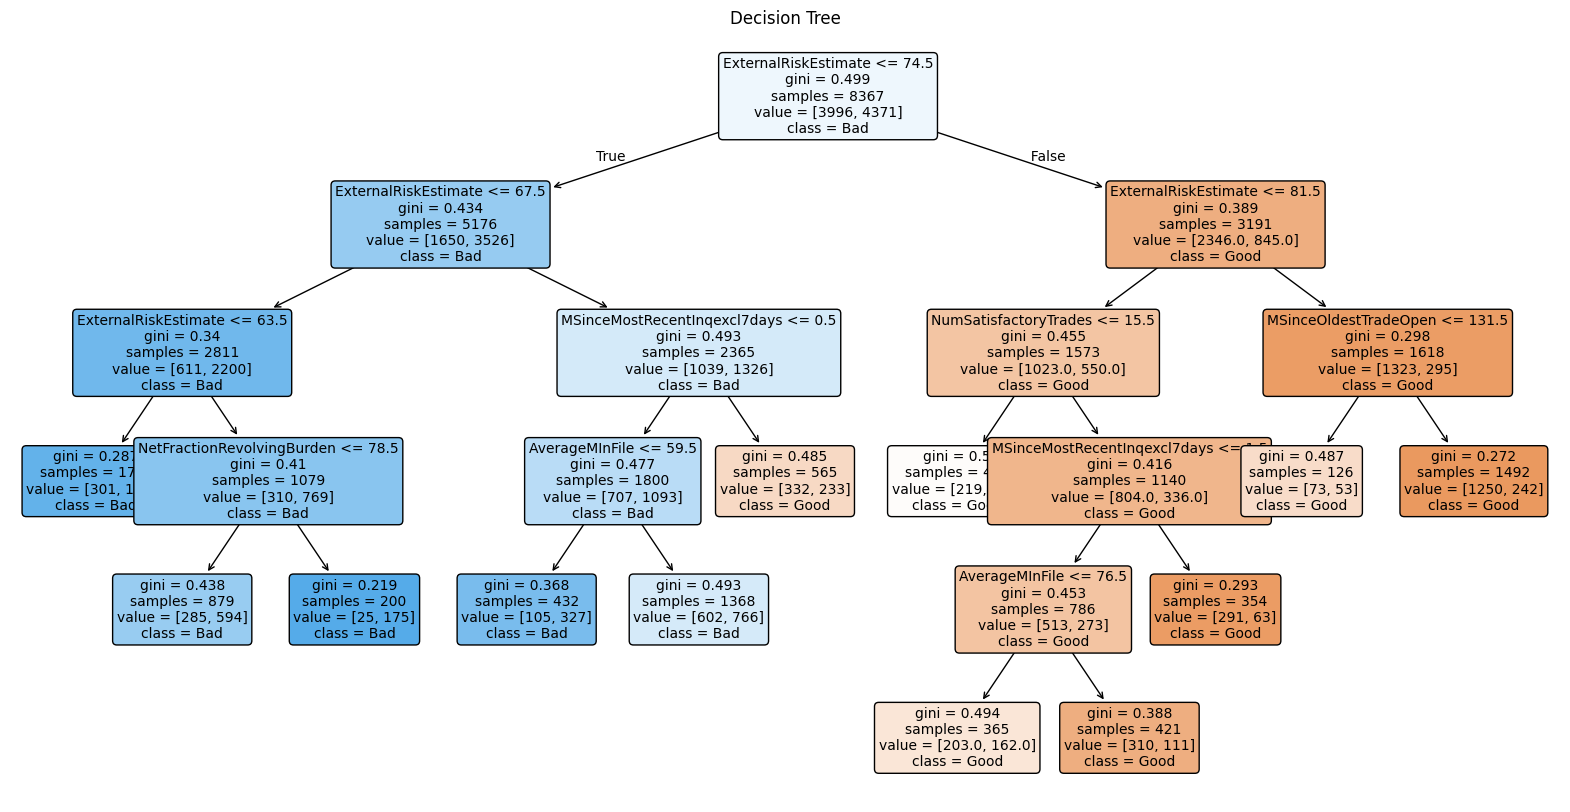

In [33]:
plt.figure(figsize=(20, 10))
plot_tree(best_dt, feature_names=X_dt.columns, class_names=['Good', 'Bad'],
          filled=True, rounded=True, max_depth=5, fontsize=10)
plt.title("Decision Tree")
plt.show()

In [19]:
feat_importances = pd.Series(best_dt.feature_importances_, index=X_dt.columns)
print(feat_importances.nlargest(10))

ExternalRiskEstimate            0.758523
MSinceMostRecentInqexcl7days    0.060239
PercentTradesWBalance           0.045181
NumSatisfactoryTrades           0.043284
AverageMInFile                  0.032202
MSinceOldestTradeOpen           0.030958
PercentInstallTrades            0.008745
PercentTradesNeverDelq          0.006509
MSinceMostRecentTradeOpen       0.005098
MaxDelq2PublicRecLast12M        0.004497
dtype: float64


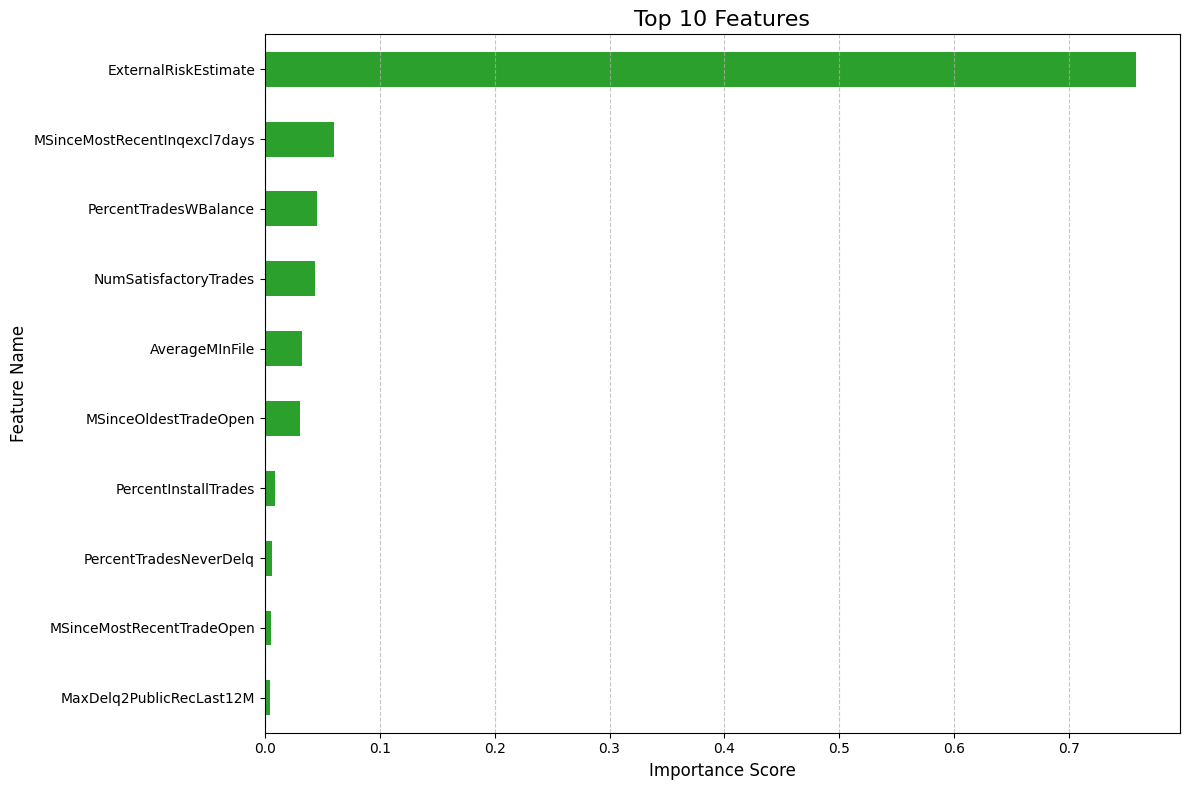

In [20]:
top_features = feat_importances.nlargest(10).sort_values()

plt.figure(figsize=(12, 8))
top_features.plot(kind='barh', color='#2ca02c')
plt.title('Top 10 Features', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Feature Engineering
Multiplied Features. But accuracy did not increase, it just added more noise

In [34]:
# Best Tree so far
best_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=20,
)

In [35]:
df_eng = df.copy()


# Multiplied Features to capture complex behaviour
df_eng['Score_x_CleanHistory'] = df_eng['ExternalRiskEstimate'] * df_eng['PercentTradesNeverDelq']
df_eng['Score_x_Age'] = df_eng['ExternalRiskEstimate'] * df_eng['AverageMInFile']
df_eng['Revolving_x_Installment_Burden'] = df_eng['NetFractionRevolvingBurden'] * df_eng['NetFractionInstallBurden']
df_eng['GoodTrades_x_TimeSinceInq'] = df_eng['NumSatisfactoryTrades'] * df_eng['MSinceMostRecentInqexcl7days']
df_eng['Age_x_GoodTrades'] = df_eng['AverageMInFile'] * df_eng['NumSatisfactoryTrades']


X_final = df_eng.drop('RiskPerformance', axis=1)
y_final = df_eng['RiskPerformance'].astype(int)

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)


best_tree.fit(X_train_final, y_train_final)


DecisionTreeClassifier(max_depth=5, min_samples_leaf=20)

In [37]:
y_pred_final = best_tree.predict(X_test_final)
acc_final = accuracy_score(y_test_final, y_pred_final)
print(f"Final Accuracy with Multiplied Features: {acc_final:.2%}")



Final Accuracy with Multiplied Features: 68.31%


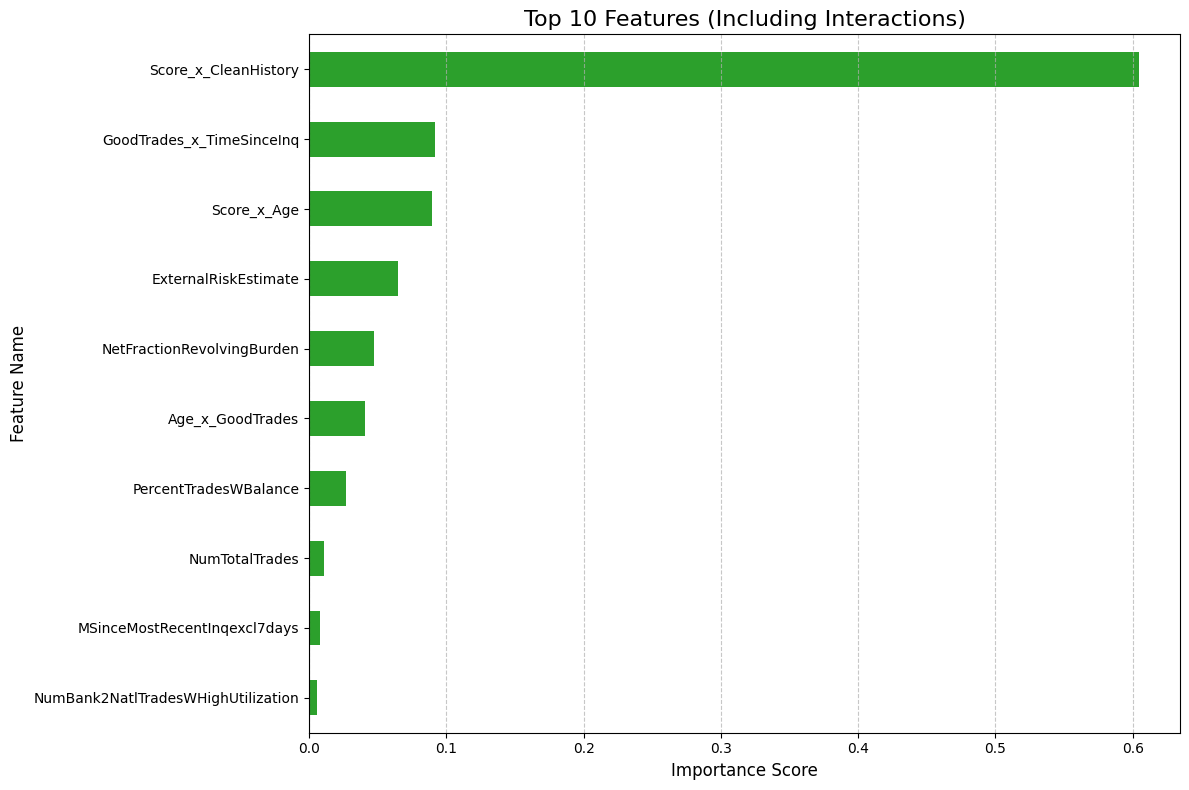

In [24]:

importances = pd.Series(best_tree.feature_importances_, index=X_final.columns)
top_features = importances.nlargest(10).sort_values()

plt.figure(figsize=(12, 8))
top_features.plot(kind='barh', color='#2ca02c')
plt.title('Top 10 Features (Including Interactions)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [25]:
#Hyperparameter Tuning

dt_params = {
    'max_depth': [5, 6, 7],
    'min_samples_leaf': [20, 40, 50],
    'criterion': ['gini', 'entropy'],
    'ccp_alpha': [0.0, 0.001, 0.0015],
}

grid_dt_2 = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt_2.fit(X_train_final, y_train_final)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'ccp_alpha': [0.0, 0.001, 0.0015],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7],
                         'min_samples_leaf': [20, 40, 50]},
             scoring='accuracy')

In [26]:
#Model performance

best_dt_2 = grid_dt_2.best_estimator_
acc_dt_2 = accuracy_score(y_test_final, best_dt_2.predict(X_test_final))

print(f" Decision Tree Accuracy: {acc_dt_2:.2%}")
print(f"   (Best Depth: {grid_dt_2.best_params_['max_depth']})")
print(f"   (Best min_samples_leaf: {grid_dt_2.best_params_['min_samples_leaf']})")
print(f"   (Best criterion: {grid_dt_2.best_params_['criterion']})")
print(f"   (Best ccp_alpha: {grid_dt_2.best_params_['ccp_alpha']})")

 Decision Tree Accuracy: 67.93%
   (Best Depth: 5)
   (Best min_samples_leaf: 40)
   (Best criterion: gini)
   (Best ccp_alpha: 0.0)
